In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
logistics = pd.read_csv(r"C:\Users\HP\Downloads\WORK\Logistics shipment\logistics_shipments_dataset.csv")

In [5]:
logistics.head()

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
0,SH10000,Warehouse_MIA,San Francisco,UPS,2023-10-02,2023-10-04,25.7,67.46,Delivered,291,2
1,SH10001,Warehouse_MIA,Atlanta,DHL,2023-12-06,2023-12-09,38.9,268.85,Delivered,1225,3
2,SH10002,Warehouse_LA,Houston,DHL,2023-09-18,2023-09-20,37.2,74.35,Delivered,220,2
3,SH10003,Warehouse_BOS,Seattle,OnTrac,2023-01-26,2023-02-04,42.6,187.04,Delivered,1156,9
4,SH10004,Warehouse_SF,Dallas,OnTrac,2023-06-03,2023-06-06,7.9,120.01,Delivered,1017,3


In [6]:
logistics.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Shipment_ID       2000 non-null   str    
 1   Origin_Warehouse  2000 non-null   str    
 2   Destination       2000 non-null   str    
 3   Carrier           2000 non-null   str    
 4   Shipment_Date     2000 non-null   str    
 5   Delivery_Date     1968 non-null   str    
 6   Weight_kg         2000 non-null   float64
 7   Cost              1959 non-null   float64
 8   Status            2000 non-null   str    
 9   Distance_miles    2000 non-null   int64  
 10  Transit_Days      2000 non-null   int64  
dtypes: float64(2), int64(2), str(7)
memory usage: 172.0 KB


In [7]:
logistics.describe()

,Weight_kg,Cost,Distance_miles,Transit_Days
count,2000.000000,1959.000000,2000.000000,2000.000000
mean,30.184800,205.161598,1275.868000,4.182500
std,124.967053,222.586082,691.382829,1.837902
min,0.000000,17.890000,101.000000,1.000000
25%,12.300000,117.710000,690.250000,3.000000
50%,20.700000,196.420000,1262.500000,4.000000
75%,33.925000,272.115000,1867.250000,5.000000
max,5404.200000,6562.210000,2499.000000,12.000000


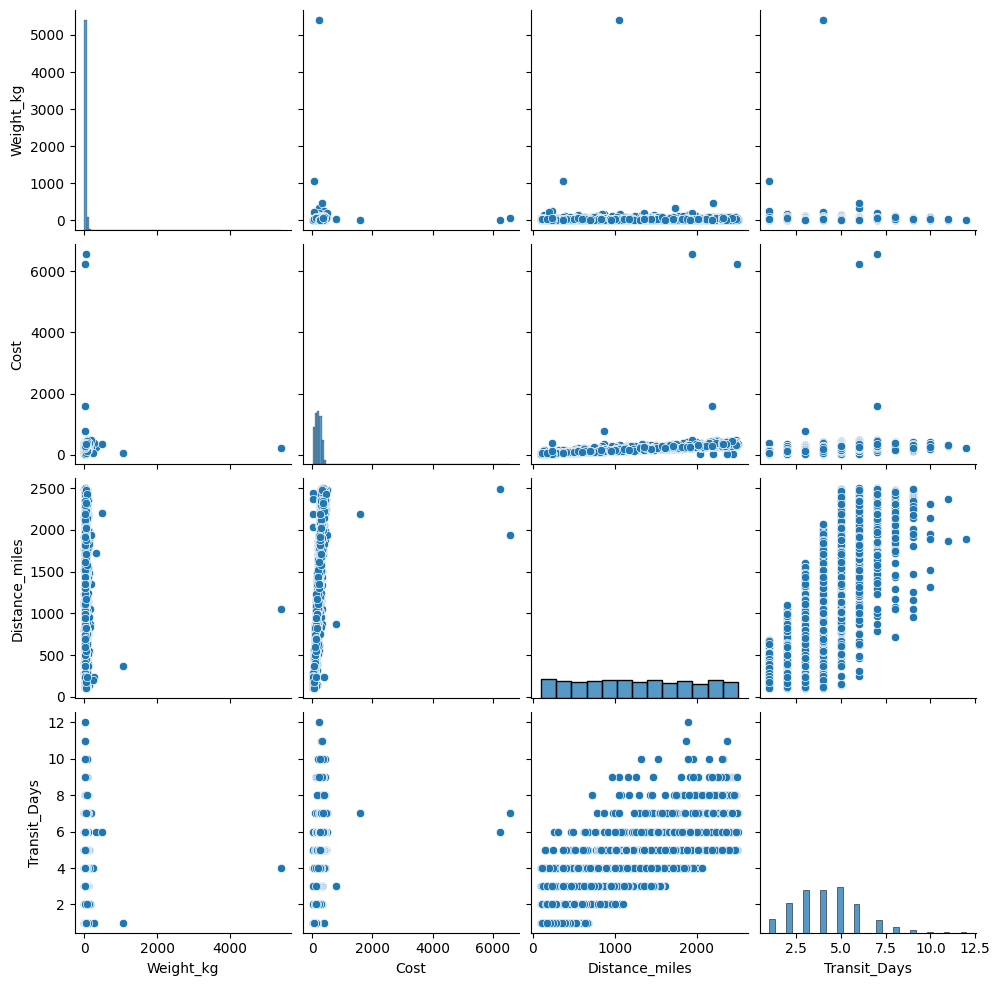

In [8]:
#plot to check the distribution of the data
sns.pairplot(logistics)
plt.show()

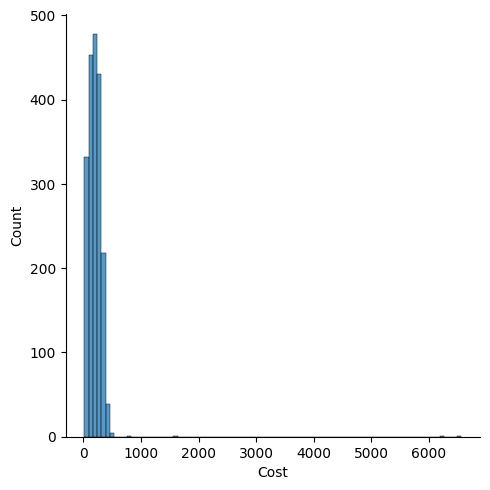

In [12]:
sns.displot(logistics["Cost"])
plt.show()

In [13]:
#filling the missing values in the "Cost" column with the median value of the "cost" column
logistics["Cost"] = logistics["Cost"].fillna(logistics["Cost"].median())

In [14]:
print(logistics.columns)

Index(['Shipment_ID', 'Origin_Warehouse', 'Destination', 'Carrier',
       'Shipment_Date', 'Delivery_Date', 'Weight_kg', 'Cost', 'Status',
       'Distance_miles', 'Transit_Days'],
      dtype='str')


In [9]:
# converted the "Shipment_Date" column to datetime format and extracted the month and day of the week from it
logistics["Shipment_Date"] = pd.to_datetime(logistics["Shipment_Date"])
logistics["month"] = logistics["Shipment_Date"].dt.month
logistics["day_of_week"] = logistics["Shipment_Date"].dt.dayofweek

In [10]:
# dropped the original "Shipment_Date" column as it is no longer needed
logistics.drop("Shipment_Date", axis=1, inplace=True)

In [11]:
# dropped the "Shipment_ID" and "Delivery_Date" columns as they are not relevant for our analysis too
logistics.drop(columns=["Shipment_ID", "Delivery_Date"], inplace=True)

In [12]:
# created dummy variables for the categorical columns and dropped the first category to avoid multicollinearity
logistics = pd.get_dummies(logistics, drop_first=True)

In [ ]:
# checked the first 10 rows of the cleaned dataset
logistics.head(10)

,Weight_kg,Cost,Distance_miles,Transit_Days,month,day_of_week,Origin_Warehouse_Warehouse_BOS,Origin_Warehouse_Warehouse_CHI,Origin_Warehouse_Warehouse_DEN,Origin_Warehouse_Warehouse_HOU,...,Carrier_DHL,Carrier_FedEx,Carrier_LaserShip,Carrier_OnTrac,Carrier_UPS,Carrier_USPS,Status_Delivered,Status_In Transit,Status_Lost,Status_Returned
0,25.7,67.46,291,2,10,0,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
1,38.9,268.85,1225,3,12,2,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
2,37.2,74.35,220,2,9,0,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,42.6,187.04,1156,9,1,3,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,7.9,120.01,1017,3,6,5,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
5,9.1,143.26,898,3,9,2,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
6,0.4,225.23,1522,4,10,3,True,False,False,False,...,False,False,False,False,True,False,True,False,False,False
7,16.7,281.23,2013,9,2,0,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
8,15.1,341.93,2072,7,11,4,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
9,27.7,55.24,214,2,1,3,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False


In [14]:
# defined the target variable (y)
y = logistics["Transit_Days"]

In [15]:
# defined the feature variables (X) by dropping the target variable from the dataset
X = logistics.drop("Transit_Days", axis=1)

In [16]:
# split the data into training and testing sets using the train_test_split function from scikit-learn
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
#fitted a linear regression model on the training data using the LinearRegression class from scikit-learn
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
# made predictions on the test set using the predict method of the trained model
y_pred = model.predict(X_test)

In [19]:
# evaluated the performance of the model using the mean absolute error and R2 score metrics from scikit-learn
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.9495531019015244
R2 Score: 0.5603231425235617


In [20]:
####------------------------------------Buidling a model for the cost prediction
# defined the target variable (y) for cost prediction
y = logistics["Cost"]

In [21]:
# defined the feature variables (X) for cost prediction by dropping the target variable from the dataset
X = logistics.drop("Cost", axis=1)

In [22]:
# split the data into training and testing sets using the train_test_split function from scikit-learn again for the cost prediction model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
#imported the StandardScaler class from scikit-learn to standardize the feature variables for the cost prediction model
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
#fitted a linear regression model on the training data for cost prediction using the LinearRegression class from scikit-learn
from sklearn.linear_model import LinearRegression

model_cost = LinearRegression()
model_cost.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
# made predictions on the test set for cost prediction using the predict method of the trained model
y_pred_cost = model_cost.predict(X_test)

In [27]:
# evaluated the performance of the cost prediction model using the mean absolute error and R2 score metrics from scikit-learn
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_cost))
print("R2 Score:", r2_score(y_test, y_pred_cost))

MAE: 47.55592929083283
R2 Score: 0.09773411678488342
